# Replicating Sarkar & Etemad (2020) on AMIGOS (40 participants)
This notebook follows the **authors' public code** ([github.com/pritamqu/SSL-ECG](https://github.com/pritamqu/SSL-ECG): `main.py`, `model.py`, `utils.py`, `data_preprocessing.py`, `signal_transformation_task.py`) as closely as our data allows. Where the code and the paper disagree, the code is used.

| Setting | Paper text | Authors' code (used here) |
|---|---|---|
| Scaling transformation | 0.9 | 1.1 |
| Pretext loss weights | not stated | 0.195 for five tasks, 0.0125 for negation and time-reversal |
| Activations | ReLU | LeakyReLU (slope 0.2) |
| Pretext regularisation | not stated | L2 1e-4 on all weights, LR decay 0.9 every 10k steps |
| Emotion network | 3×512, dropout 40%, L2 1e-4, 250 epochs | 3×512, dropout 40%, **no** L2, 200 epochs |
| Emotion labels | binary, split at the mean | ratings **rounded to 9 classes**; "valence" is read from the **dominance** column |
| Normalisation | per-participant z-score | per-participant; std taken over the central 95% of values |
| When emotion is evaluated | not stated | after **every** pretext epoch |
| Split | shuffled 10-fold | `KFold(10, shuffle=True, random_state=1)` over all windows |

**What we still cannot match:** the authors used raw 256 Hz ECG (we have the 128 Hz preprocessed release, upsampled), and they pre-trained stage 1 on AMIGOS + DREAMER + WESAD + SWELL together.

**Outputs:** binary and 9-class results for arousal, valence and dominance; the fully-supervised CNN baseline; and the same models under `trial_10fold` (all windows of a video kept together) as a leakage check.

Use the **`torch`** conda environment as the kernel. Default runtime on an RTX 5060: about 1.5–2 h.

In [1]:
# ===== EDIT THIS =====
ROOT = r"C:\Users\User\Desktop\VS_CODE\Sahi\AMIGOS PreProcessed"   # contains the Data_Preprocessed_Pxx folders
# ====================

# ---- data (authors' data_preprocessing.py) ----
ECG_CHANNEL = 14          # joined_data columns: 0-13 EEG, 14 = ECG right, 15 = ECG left, 16 = GSR
FS_IN, FS = 128, 256      # released preprocessed data is 128 Hz; the network expects 256 Hz (2560 samples / 10 s)
WIN_SEC = 10              # non-overlapping windows
HIGHPASS_HZ = 0.8         # baseline-wander removal (paper §4.2)
DIMENSIONS = ["arousal", "valence", "dominance"]   # dominance included because the authors' "valence" is dominance

# ---- stage 1: signal-transformation recognition (authors' main.py) ----
SNR_DB, SCALE, N_PERM, N_WARP, STRETCH = 15, 1.1, 20, 9, 1.05
LOSS_COEFF = [0.195, 0.195, 0.195, 0.0125, 0.0125, 0.195, 0.195]  # original, noise, scale, negate, flip, permute, warp
PRETEXT_EPOCHS = 100
PRETEXT_BATCH = 128       # windows per step; each window plus its 6 transformations -> 896 samples per step
LR, LR_DECAY_STEPS, LR_DECAY = 1e-3, 10000, 0.9
PRETEXT_L2, PRETEXT_DROPOUT = 1e-4, 0.6
EVAL_EPOCHS = [10, 25, 50, 75, 100]   # the authors trained the emotion model after every pretext epoch; we sample 5
PRETEXT_PER_FOLD = False  # authors: True (a new pretext model per fold, ~4 h). False: trained once on all windows
                          # (~25 min). Stage 1 never sees labels either way.

# ---- stage 2: emotion recognition (authors' model.supervised_model_amigos) ----
EMOTION_EPOCHS, EMOTION_BATCH, EMOTION_DROPOUT = 200, 128, 0.4

# ---- extras ----
RUN_SUPERVISED = True     # paper's fully-supervised CNN (paper: 84.4% / 81.1%), ~70 min
SCHEMES = ["paper_10fold", "trial_10fold"]
SEED = 1                  # authors: KFold(..., random_state=True), i.e. 1

In [2]:
import copy, re, time, warnings
from pathlib import Path
import numpy as np, pandas as pd, scipy.io as sio
from scipy import signal
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = DEVICE.type == "cuda"
torch.backends.cudnn.benchmark = True
np.random.seed(SEED); torch.manual_seed(SEED)
WIN = FS * WIN_SEC
print("device:", DEVICE, torch.cuda.get_device_name(0) if AMP else "")

device: cuda NVIDIA GeForce RTX 5060 Laptop GPU


## 1) Load ECG and self-assessed arousal, valence, dominance

In [3]:
def load_amigos(root, ch=ECG_CHANNEL):
    files = sorted(Path(root).rglob("Data_Preprocessed_P*.mat"))
    if not files:
        raise FileNotFoundError(f"No Data_Preprocessed_P*.mat under {root}")
    trials, skipped = [], []
    for fp in files:
        pid = int(re.search(r"P(\d+)", fp.stem).group(1))
        m = sio.loadmat(fp, squeeze_me=True)
        for i, (x, lab, vid) in enumerate(zip(m["joined_data"], m["labels_selfassessment"], m["VideoIDs"])):
            if i >= 16:                    # the authors' label file only covers the 16 short videos
                continue
            x = np.asarray(x, float)
            lab = np.atleast_1d(np.asarray(lab, float))
            if x.ndim != 2 or len(x) < FS_IN * WIN_SEC or lab.size < 3 or np.isnan(lab[:3]).any():
                skipped.append((pid, i + 1, "no data/label"))
                continue
            if np.isnan(x[:, ch]).any() or np.nanstd(x[:, ch]) == 0:   # e.g. P09
                skipped.append((pid, i + 1, "ECG missing"))
                continue
            trials.append(dict(pid=pid, trial=i + 1, video=str(vid), ecg=x[:, ch],
                               arousal=lab[0], valence=lab[1], dominance=lab[2]))
    return trials, skipped


trials, skipped = load_amigos(ROOT)
print(f"{len(trials)} trials from {len({t['pid'] for t in trials})} participants; skipped {len(skipped)}:", skipped)

629 trials from 40 participants; skipped 11: [(9, 1, 'ECG missing'), (9, 2, 'ECG missing'), (9, 3, 'ECG missing'), (9, 6, 'ECG missing'), (9, 7, 'ECG missing'), (9, 9, 'ECG missing'), (9, 11, 'ECG missing'), (9, 12, 'ECG missing'), (9, 13, 'ECG missing'), (9, 15, 'ECG missing'), (9, 16, 'ECG missing')]


## 2) Pre-processing and labels (authors' `data_preprocessing.py`)
High-pass 0.8 Hz → 256 Hz → per-participant normalisation (mean of all samples, std of the central 95%) → 10-s windows. Each window gets its video's rating.

Labels: `*_bin` = above the mean rating (paper Table 6); `*_9` = rating rounded to an integer (authors' code, paper Table 5).

In [4]:
SOS_HP = signal.butter(4, HIGHPASS_HZ, btype="highpass", fs=FS_IN, output="sos")


def preprocess_trial(ecg):
    y = signal.sosfiltfilt(SOS_HP, ecg)
    return signal.resample_poly(y, FS, FS_IN) if FS != FS_IN else y


def build_windows(trials):
    X, meta = [], []
    for pid in sorted({t["pid"] for t in trials}):
        sig = [(t, preprocess_trial(t["ecg"])) for t in trials if t["pid"] == pid]
        allv = np.sort(np.concatenate([s for _, s in sig]))
        n = len(allv)
        mu, sd = allv.mean(), allv[int(0.025 * n):int(0.975 * n)].std()
        for t, s in sig:
            s = (s - mu) / sd
            for w in range(len(s) // WIN):
                X.append(s[w * WIN:(w + 1) * WIN])
                meta.append(dict(pid=pid, trial=t["trial"], video=t["video"], window=w,
                                 **{d: t[d] for d in DIMENSIONS}))
    return np.stack(X).astype(np.float32), pd.DataFrame(meta)


X, meta = build_windows(trials)
for d in DIMENSIONS:
    meta[f"{d}_bin"] = (meta[d] > meta[d].mean()).astype(int)
    r = np.round(meta[d]).astype(int)
    meta[f"{d}_9"] = r - r.min()

TARGETS = [f"{d}_{k}" for k in ("bin", "9") for d in DIMENSIONS]
N_CLASSES = [int(meta[t].max()) + 1 for t in TARGETS]
CHANCE = {t: meta[t].value_counts(normalize=True).max() for t in TARGETS}
print("windows:", X.shape)
print(pd.DataFrame({"classes": N_CLASSES, "majority_share": [CHANCE[t] for t in TARGETS]}, index=TARGETS).round(3))

windows: (5499, 2560)
               classes  majority_share
arousal_bin          2           0.520
valence_bin          2           0.553
dominance_bin        2           0.543
arousal_9            9           0.215
valence_9            9           0.194
dominance_9          9           0.211


## 3) Signal transformations (authors' `signal_transformation_task.py` and `utils.make_batch`)

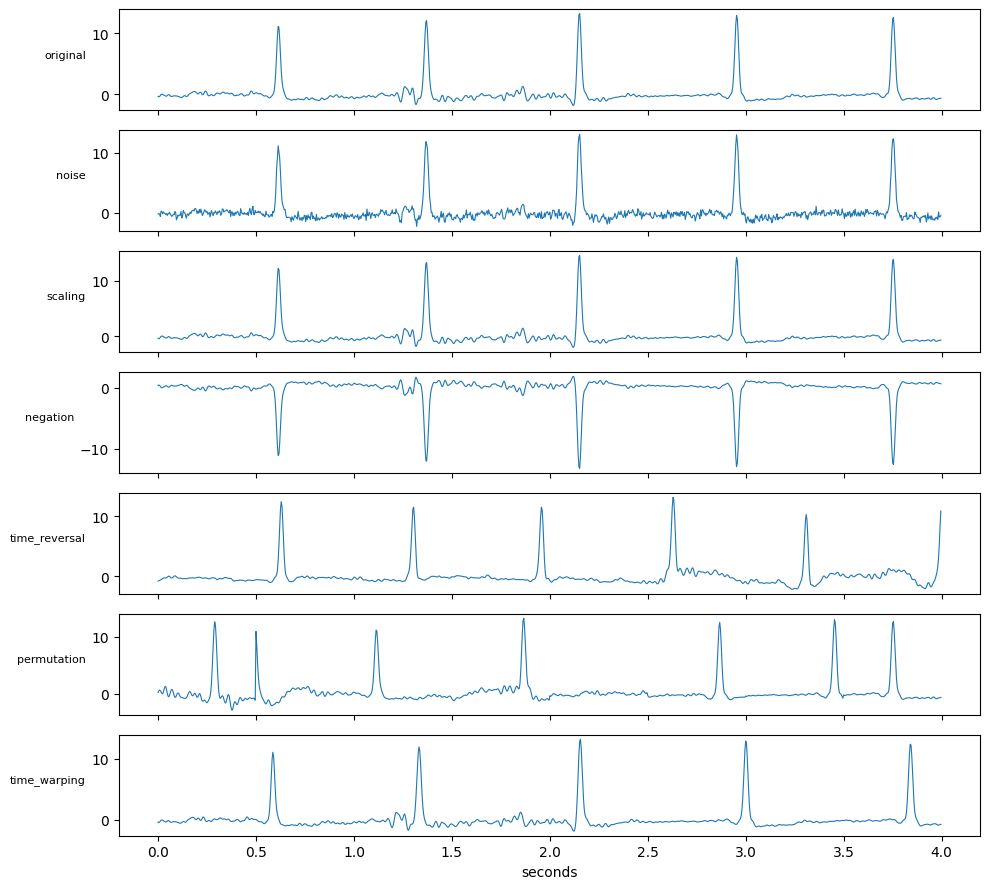

In [5]:
def add_noise(x, rng):
    noise_db = 10 * np.log10(np.mean(x ** 2)) - SNR_DB
    return x + rng.normal(0, np.sqrt(10 ** (noise_db / 10)), len(x))


def scale(x, rng):
    return SCALE * x


def negate(x, rng):
    return -x


def flip(x, rng):
    return x[::-1]


def permute(x, rng):
    k = len(x) // N_PERM
    pieces = [x[i * k:(i + 1) * k] for i in range(N_PERM)]
    return np.concatenate([pieces[i] for i in rng.permutation(N_PERM)])


def time_warp(x, rng):
    # 9 segments of floor(10/9 s); ceil(9/2) random segments stretched x1.05, the rest squeezed /1.05,
    # then a random crop back to the original length (authors' make_batch)
    seg = int(np.floor(WIN_SEC / N_WARP * FS))
    stretch = set(rng.choice(N_WARP, int(np.ceil(N_WARP / 2)), replace=False).tolist())
    out = []
    for i in range(N_WARP):
        s = x[i * seg:(i + 1) * seg]
        n = int(np.ceil(len(s) * (STRETCH if i in stretch else 1 / STRETCH)))
        out.append(np.interp(np.linspace(0, len(s) - 1, n), np.arange(len(s)), s))
    y = np.concatenate(out)
    if len(y) > len(x):
        start = rng.integers(0, len(y) - len(x))
        return y[start:start + len(x)]
    return np.pad(y, (0, len(x) - len(y)))


TRANSFORMS = [("original", None), ("noise", add_noise), ("scaling", scale), ("negation", negate),
              ("time_reversal", flip), ("permutation", permute), ("time_warping", time_warp)]


def make_pretext_batch(xb, rng):
    # every window together with its 6 transformations; label = transformation index
    xs = [xb] + [np.stack([fn(x, rng) for x in xb]) for _, fn in TRANSFORMS[1:]]
    return np.concatenate(xs).astype(np.float32), np.repeat(np.arange(len(TRANSFORMS)), len(xb))


xp, _ = make_pretext_batch(X[:1], np.random.default_rng(SEED))
fig, axes = plt.subplots(len(TRANSFORMS), 1, figsize=(10, 9), sharex=True)
for ax, x, (name, _) in zip(axes, xp, TRANSFORMS):
    ax.plot(np.arange(FS * 4) / FS, x[:FS * 4], lw=0.8)
    ax.set_ylabel(name, rotation=0, ha="right", fontsize=8)
axes[-1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 4) Networks (authors' `model.py`)
- **Encoder:** Conv1D 32×k32 ×2 → max-pool 8/2 → 64×k16 ×2 → max-pool 8/2 → 128×k8 ×2 → global max-pool (128-d). LeakyReLU(0.2), Glorot init (TensorFlow defaults).
- **Pretext heads:** 7 branches of Dense 128 → Dense 128 (LeakyReLU, dropout 0.6) → 1 logit.
- **Emotion network:** 3 × Dense 512 (ReLU, dropout 0.4) → softmax. One independent network per target; the 6 targets are trained side by side with batched matrix multiplies, which is the same as training them separately.
- **Fully-supervised CNN:** a fresh encoder + the emotion network, trained end to end.

In [6]:
def act():
    return nn.LeakyReLU(0.2)                 # tf.nn.leaky_relu default slope


def glorot_(m):
    if isinstance(m, (nn.Conv1d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        def block(cin, cout, k):
            return [nn.Conv1d(cin, cout, k, padding="same"), act(), nn.Conv1d(cout, cout, k, padding="same"), act()]

        self.net = nn.Sequential(*block(1, 32, 32), nn.MaxPool1d(8, 2),
                                 *block(32, 64, 16), nn.MaxPool1d(8, 2),
                                 *block(64, 128, 8))
        self.apply(glorot_)

    def forward(self, x):                        # (B, 2560) -> (B, 128)
        return self.net(x.unsqueeze(1)).amax(-1)


class PretextNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.heads = nn.ModuleList([nn.Sequential(
            nn.Linear(128, 128), act(), nn.Dropout(PRETEXT_DROPOUT),
            nn.Linear(128, 128), act(), nn.Dropout(PRETEXT_DROPOUT),
            nn.Linear(128, 1)) for _ in TRANSFORMS])
        self.heads.apply(glorot_)

    def forward(self, x):
        z = self.encoder(x)
        return torch.cat([h(z) for h in self.heads], 1)   # (B, 7) logits


def glorot(h, a, b):
    bound = np.sqrt(6 / (a + b))
    return torch.empty(h, a, b).uniform_(-bound, bound)


class MultiMLP(nn.Module):
    # H independent emotion networks (3 x Dense 512, ReLU, dropout 0.4) evaluated in one pass
    def __init__(self, n_heads, d_in, n_out, hidden=512, p=EMOTION_DROPOUT):
        super().__init__()
        dims = [d_in, hidden, hidden, hidden, n_out]
        self.W = nn.ParameterList([nn.Parameter(glorot(n_heads, a, b)) for a, b in zip(dims[:-1], dims[1:])])
        self.b = nn.ParameterList([nn.Parameter(torch.zeros(n_heads, 1, b)) for b in dims[1:]])
        self.drop = nn.Dropout(p)

    def forward(self, z):                        # (B, d_in) -> (H, B, n_out)
        x = z.unsqueeze(0).expand(len(self.W[0]), -1, -1)
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            x = torch.baddbmm(b, x, W)
            if i < len(self.W) - 1:
                x = self.drop(F.relu(x))
        return x


class SupervisedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.heads = MultiMLP(len(TARGETS), 128, max(N_CLASSES))

    def forward(self, x):
        return self.heads(self.encoder(x))

## 5) Stage 1: transformation recognition
Fresh random transformations every epoch (as in the authors' batch generator). Loss = weighted sum of the 7 sigmoid cross-entropies + L2 1e-4 on all weights. Encoder snapshots are kept at `EVAL_EPOCHS`.

In [7]:
COEFF = torch.tensor(LOSS_COEFF, device=DEVICE)


def pretext_loss(model, logits, y):
    per_task = F.binary_cross_entropy_with_logits(logits, F.one_hot(y, len(TRANSFORMS)).float(),
                                                  reduction="none").mean(0)
    l2 = sum((p.float() ** 2).sum() for n, p in model.named_parameters() if n.endswith("weight")) / 2
    return (COEFF * per_task).sum() + PRETEXT_L2 * l2


def train_pretext(Xs, seed, log=True):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    model = PretextNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.StepLR(opt, LR_DECAY_STEPS, LR_DECAY)   # per step = TF staircase decay
    scaler = torch.amp.GradScaler(enabled=AMP)
    ckpts, t0 = {}, time.time()
    for ep in range(1, PRETEXT_EPOCHS + 1):
        model.train()
        order = rng.permutation(len(Xs))
        for i in range(0, len(Xs), PRETEXT_BATCH):
            xb, yb = make_pretext_batch(Xs[order[i:i + PRETEXT_BATCH]], rng)
            xb, yb = torch.from_numpy(xb).to(DEVICE), torch.from_numpy(yb).to(DEVICE)
            with torch.autocast(DEVICE.type, enabled=AMP):
                logits = model(xb)
            loss = pretext_loss(model, logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        if ep in EVAL_EPOCHS:
            ckpts[ep] = copy.deepcopy(model.encoder.state_dict())
        if log and (ep == 1 or ep % 10 == 0):
            print(f"  pretext epoch {ep:3d}/{PRETEXT_EPOCHS}  loss {loss.item():.4f}  ({(time.time() - t0) / 60:.1f} min)")
    return model, ckpts


@torch.no_grad()
def pretext_accuracy(model, Xs, seed):
    # per-task accuracy on freshly transformed windows (compare with paper Table 4: 0.97-1.00)
    rng = np.random.default_rng(seed)
    model.eval()
    hits, n = np.zeros(len(TRANSFORMS)), 0
    for i in range(0, len(Xs), PRETEXT_BATCH):
        xb, yb = make_pretext_batch(Xs[i:i + PRETEXT_BATCH], rng)
        with torch.autocast(DEVICE.type, enabled=AMP):
            p = model(torch.from_numpy(xb).to(DEVICE)).float().sigmoid().cpu().numpy() > 0.5
        hits += (p == np.eye(len(TRANSFORMS), dtype=bool)[yb]).sum(0)
        n += len(yb)
    return {name: round(float(a), 3) for (name, _), a in zip(TRANSFORMS, hits / n)}


@torch.no_grad()
def embed(state, Xt, bs=512):
    enc = Encoder().to(DEVICE)
    enc.load_state_dict(state)
    enc.eval()
    out = []
    for i in range(0, len(Xt), bs):
        with torch.autocast(DEVICE.type, enabled=AMP):
            out.append(enc(Xt[i:i + bs]).float())
    return torch.cat(out)

## 6) Stage 2 helpers and cross-validation splits

In [8]:
def heads_loss(out, y):
    return sum(F.cross_entropy(out[h, :, :n], y[:, h]) for h, n in enumerate(N_CLASSES))


def fit_emotion(model, Xtr, Ytr, seed, amp=False):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    scaler = torch.amp.GradScaler(enabled=amp)
    gen = torch.Generator().manual_seed(seed)
    for _ in range(EMOTION_EPOCHS):
        model.train()
        idx = torch.randperm(len(Xtr), generator=gen).to(DEVICE)
        for i in range(0, len(Xtr), EMOTION_BATCH):
            b = idx[i:i + EMOTION_BATCH]
            with torch.autocast(DEVICE.type, enabled=amp):
                out = model(Xtr[b])
            loss = heads_loss(out.float(), Ytr[b])
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
    return model


@torch.no_grad()
def predict(model, Xt, bs=512, amp=False):
    model.eval()
    out = []
    for i in range(0, len(Xt), bs):
        with torch.autocast(DEVICE.type, enabled=amp):
            o = model(Xt[i:i + bs]).float()
        out.append(torch.stack([o[h, :, :n].argmax(1) for h, n in enumerate(N_CLASSES)], 1))
    return torch.cat(out).cpu().numpy()


def folds(scheme):
    idx = np.arange(len(meta))
    if scheme == "paper_10fold":
        return list(KFold(10, shuffle=True, random_state=SEED).split(idx))
    if scheme == "trial_10fold":
        return list(GroupKFold(10).split(idx, groups=meta.pid * 100 + meta.trial))
    raise ValueError(scheme)


Xall = torch.from_numpy(X).to(DEVICE)
Ynp = meta[TARGETS].to_numpy()
Yall = torch.from_numpy(Ynp).long().to(DEVICE)
SPLITS = {s: folds(s) for s in SCHEMES}
rows = []


def fit_and_record(Z, scheme, model_name, epoch, k, tr, te):
    tr_t, te_t = torch.from_numpy(tr).to(DEVICE), torch.from_numpy(te).to(DEVICE)
    torch.manual_seed(SEED + k)
    heads = fit_emotion(MultiMLP(len(TARGETS), Z.shape[1], max(N_CLASSES)).to(DEVICE), Z[tr_t], Yall[tr_t], SEED + k)
    p_tr, p_te = predict(heads, Z[tr_t]), predict(heads, Z[te_t])
    for h, t in enumerate(TARGETS):
        rows.append(dict(scheme=scheme, model=model_name, pretext_epoch=epoch, fold=k, target=t,
                         train_acc=accuracy_score(Ynp[tr, h], p_tr[:, h]),
                         test_acc=accuracy_score(Ynp[te, h], p_te[:, h]),
                         test_f1=f1_score(Ynp[te, h], p_te[:, h], average="macro")))


def progress(scheme, epoch):
    d = pd.DataFrame(rows)
    d = d[(d.scheme == scheme) & (d.model == "self_supervised") & (d.pretext_epoch == epoch)]
    return d.groupby("target").test_acc.mean().reindex(TARGETS).round(3).to_dict()

## 7) Run: self-supervised model (stage 1 → frozen encoder → emotion network)

In [9]:
t_all = time.time()
if not PRETEXT_PER_FOLD:
    pre, ckpts = train_pretext(X, SEED)
    print("pretext accuracy on freshly transformed windows:", pretext_accuracy(pre, X, SEED + 1))
    for ep, state in ckpts.items():
        Z = embed(state, Xall)
        for scheme in SCHEMES:
            for k, (tr, te) in enumerate(SPLITS[scheme]):
                fit_and_record(Z, scheme, "self_supervised", ep, k, tr, te)
            print(f"[pretext epoch {ep}] {scheme} test acc:", progress(scheme, ep))
else:
    for scheme in SCHEMES:
        for k, (tr, te) in enumerate(SPLITS[scheme]):
            t0 = time.time()
            pre, ckpts = train_pretext(X[tr], SEED + k, log=False)
            if k == 0:
                print(f"[{scheme}] pretext accuracy on the held-out fold:", pretext_accuracy(pre, X[te], SEED + k))
            for ep, state in ckpts.items():
                fit_and_record(embed(state, Xall), scheme, "self_supervised", ep, k, tr, te)
            print(f"[{scheme}] fold {k + 1}/10 done in {(time.time() - t0) / 60:.1f} min")
print(f"self-supervised part finished in {(time.time() - t_all) / 60:.1f} min")

  pretext epoch   1/100  loss 0.4212  (0.5 min)
  pretext epoch  10/100  loss 0.1252  (2.7 min)
  pretext epoch  20/100  loss 0.0816  (5.1 min)
  pretext epoch  30/100  loss 0.0483  (7.5 min)
  pretext epoch  40/100  loss 0.0622  (10.0 min)
  pretext epoch  50/100  loss 0.0415  (12.4 min)
  pretext epoch  60/100  loss 0.0317  (14.8 min)
  pretext epoch  70/100  loss 0.0346  (17.2 min)
  pretext epoch  80/100  loss 0.0335  (19.6 min)
  pretext epoch  90/100  loss 0.0288  (22.0 min)
  pretext epoch 100/100  loss 0.0207  (24.3 min)
pretext accuracy on freshly transformed windows: {'original': 0.998, 'noise': 1.0, 'scaling': 0.998, 'negation': 1.0, 'time_reversal': 1.0, 'permutation': 1.0, 'time_warping': 1.0}
[pretext epoch 10] paper_10fold test acc: {'arousal_bin': 0.686, 'valence_bin': 0.594, 'dominance_bin': 0.712, 'arousal_9': 0.475, 'valence_9': 0.391, 'dominance_9': 0.466}
[pretext epoch 10] trial_10fold test acc: {'arousal_bin': 0.603, 'valence_bin': 0.526, 'dominance_bin': 0.653, 

## 8) Run: fully-supervised CNN baseline (paper Table 6), paper protocol only

In [10]:
if RUN_SUPERVISED:
    t_all = time.time()
    for k, (tr, te) in enumerate(SPLITS["paper_10fold"]):
        t0 = time.time()
        tr_t, te_t = torch.from_numpy(tr).to(DEVICE), torch.from_numpy(te).to(DEVICE)
        torch.manual_seed(SEED + k)
        model = fit_emotion(SupervisedCNN().to(DEVICE), Xall[tr_t], Yall[tr_t], SEED + k, amp=AMP)
        p_tr, p_te = predict(model, Xall[tr_t], amp=AMP), predict(model, Xall[te_t], amp=AMP)
        for h, t in enumerate(TARGETS):
            rows.append(dict(scheme="paper_10fold", model="fully_supervised", pretext_epoch=0, fold=k, target=t,
                             train_acc=accuracy_score(Ynp[tr, h], p_tr[:, h]),
                             test_acc=accuracy_score(Ynp[te, h], p_te[:, h]),
                             test_f1=f1_score(Ynp[te, h], p_te[:, h], average="macro")))
        print(f"fold {k + 1}/10 done in {(time.time() - t0) / 60:.1f} min")
    print(f"fully-supervised part finished in {(time.time() - t_all) / 60:.1f} min")

fold 1/10 done in 4.6 min
fold 2/10 done in 6.3 min
fold 3/10 done in 6.2 min
fold 4/10 done in 6.2 min
fold 5/10 done in 6.3 min
fold 6/10 done in 6.3 min
fold 7/10 done in 6.3 min
fold 8/10 done in 6.3 min
fold 9/10 done in 6.3 min
fold 10/10 done in 6.9 min
fully-supervised part finished in 61.5 min


## 9) Results
Accuracies are averaged over the 10 folds, as in the paper. **`best_ckpt_test_acc`** picks the best of the 5 sampled pretext epochs using the test folds themselves. The authors' code trained and scored the emotion model after every pretext epoch, so reporting a best epoch was possible; treat that column as optimistic.

In [11]:
df = pd.DataFrame(rows)
df.to_csv("sarkar_replication_folds.csv", index=False)
summ = df.groupby(["scheme", "model", "pretext_epoch", "target"])[["train_acc", "test_acc", "test_f1"]].mean().reset_index()
summ.to_csv("sarkar_replication_summary.csv", index=False)

PAPER = {("self_supervised", "arousal_bin"): 0.889, ("self_supervised", "valence_bin"): 0.875,
         ("self_supervised", "arousal_9"): 0.796, ("self_supervised", "valence_9"): 0.783,
         ("fully_supervised", "arousal_bin"): 0.844, ("fully_supervised", "valence_bin"): 0.811}


def ssl_table(scheme):
    s = summ[(summ.scheme == scheme) & (summ.model == "self_supervised")]
    final = s[s.pretext_epoch == max(EVAL_EPOCHS)].set_index("target")
    best = s.loc[s.groupby("target").test_acc.idxmax()].set_index("target")
    tab = pd.DataFrame({
        "chance": pd.Series(CHANCE),
        "train_acc": final.train_acc,
        f"test_acc (epoch {max(EVAL_EPOCHS)})": final.test_acc,
        "test_f1": final.test_f1,
        "best_ckpt_test_acc": best.test_acc,
        "best_epoch": best.pretext_epoch,
    }).loc[TARGETS]
    if scheme == "paper_10fold":
        tab["paper"] = [PAPER.get(("self_supervised", t)) for t in TARGETS]
    return tab


for scheme in SCHEMES:
    print(f"\nSelf-supervised, {scheme}")
    display(ssl_table(scheme).round(3))

if RUN_SUPERVISED:
    s = summ[summ.model == "fully_supervised"].set_index("target")
    print("\nFully-supervised CNN, paper_10fold")
    display(pd.DataFrame({"chance": pd.Series(CHANCE), "train_acc": s.train_acc, "test_acc": s.test_acc,
                          "test_f1": s.test_f1,
                          "paper": pd.Series({t: PAPER.get(("fully_supervised", t)) for t in TARGETS})})
            .loc[TARGETS].round(3))


Self-supervised, paper_10fold


,chance,train_acc,test_acc (epoch 100),test_f1,best_ckpt_test_acc,best_epoch,paper
arousal_bin,0.520,0.844,0.711,0.709,0.716,75,0.889
valence_bin,0.553,0.757,0.621,0.597,0.621,100,0.875
dominance_bin,0.543,0.866,0.745,0.742,0.745,100,NaN
arousal_9,0.215,0.881,0.528,0.449,0.528,100,0.796
valence_9,0.194,0.863,0.442,0.416,0.442,75,0.783
dominance_9,0.211,0.884,0.512,0.491,0.512,100,NaN



Self-supervised, trial_10fold


,chance,train_acc,test_acc (epoch 100),test_f1,best_ckpt_test_acc,best_epoch
arousal_bin,0.520,0.849,0.607,0.601,0.621,50
valence_bin,0.553,0.765,0.511,0.482,0.526,10
dominance_bin,0.543,0.876,0.639,0.632,0.655,25
arousal_9,0.215,0.891,0.296,0.188,0.304,25
valence_9,0.194,0.875,0.189,0.162,0.189,100
dominance_9,0.211,0.894,0.279,0.228,0.290,10



Fully-supervised CNN, paper_10fold


,chance,train_acc,test_acc,test_f1,paper
arousal_bin,0.520,0.998,0.687,0.685,0.844
valence_bin,0.553,0.998,0.570,0.560,0.811
dominance_bin,0.543,0.999,0.702,0.699,NaN
arousal_9,0.215,0.996,0.415,0.327,NaN
valence_9,0.194,0.996,0.300,0.275,NaN
dominance_9,0.211,0.996,0.395,0.362,NaN


## Notes
- **Which row to compare with the paper:** `paper_10fold`, `arousal_bin` / `valence_bin` for Table 6 and `arousal_9` / `valence_9` for Table 5. Because the authors' code reads dominance as "valence", the `dominance_*` rows are the like-for-like comparison for the paper's valence numbers.
- **`trial_10fold`** keeps every window of a video in the same fold. If `paper_10fold` is far above `trial_10fold`, the model is recognising recordings rather than emotions.
- **Train vs test in the authors' log:** in the public `model.supervised_model_amigos`, both the training-set and test-set results are appended to the same `tr_amigos_*.csv` file. That makes the two easy to mix up when reading results back; the `train_acc` column shows how different they are here.
- **Runtime knobs:** `PRETEXT_PER_FOLD=True` (~4 h extra) matches the authors' per-fold pretext training; `RUN_SUPERVISED=False` saves ~70 min.